# Multihazard Risk Screening of Rural Schools, Part 1: The Dataset

Rural school buildings in Colombia were surveyed in the field and a structural
specialist rated the risk of every building for four natural hazards:
**earthquake, landslide, flood and windstorm**. Each rating uses three levels,
Low, Medium and High. This project trains machine learning models that
reproduce the specialist judgment from the survey attributes alone, then uses
SHAP to reveal which attributes carry that judgment.

This first notebook presents the data.

**A note on confidentiality.** The survey belongs to a research project and is
not distributed here. The loader falls back to a synthetic demonstration
dataset with the identical schema (see `data/README.md`), so every notebook
runs end to end for anyone cloning the repository. The outputs stored in this
notebook come from the real survey. Only aggregate views and a five row
glimpse of the records are shown.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "schoolrisk").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd

from schoolrisk.config import HAZARDS, TARGET, RISK_LEVELS
from schoolrisk.data import load_dataset, resolve_data_file, class_counts
from schoolrisk.plots import apply_style, class_balance_figure, SEQ_CMAP

apply_style()

## 1. Survey dictionary

All attributes are categorical. Within each hazard, the admissible values of
every attribute are ordered from the most favorable condition to the least
favorable one, following the specialist criteria. That ordering matters twice:
it is how the field forms were designed, and it is how the features will be
encoded for the models.

The four hazards share a structural core (system, period, stories, openings,
quality, damage) and add hazard specific attributes such as the flood barrier
or the roof geometry.

In [3]:
rows = []
for hazard, schema in HAZARDS.items():
    for feature, values in schema.features.items():
        rows.append(
            {
                "Hazard": schema.display,
                "Attribute": schema.display_name(feature),
                "Admissible values, favorable to unfavorable": "  <  ".join(values),
            }
        )
dictionary = pd.DataFrame(rows)
dictionary.groupby("Hazard").size().rename("Attributes").to_frame().T

Hazard,Earthquake,Flood,Landslide,Windstorm
Attributes,12,7,12,10


In [4]:
with pd.option_context("display.max_colwidth", None, "display.max_rows", 50):
    display(dictionary[dictionary["Hazard"] == "Earthquake"].drop(columns="Hazard"))

,Attribute,"Admissible values, favorable to unfavorable"
0,Structural system,Timber < Reinforced concrete frame < Confined brick masonry < Concrete block masonry < Partially confined brick masonry < Unreinforced brick masonry < Earthen construction < Mixed or informal system
1,Construction period,After 2010 < 2001 to 2010 < 1980 to 2000 < Before 1980
2,Number of stories,1 < 2 < 3 or more
3,Facade openings,0 to 2 < 3 to 5 < More than 5
4,Construction quality,Good < Moderate < Poor
5,Visible structural damage,No < Yes
6,Ring beam at wall tops,Yes < No
7,Wall to wall connections,Yes < No
8,Plan configuration,Regular < Irregular
9,Roof covering,Clay tiles < Fiber cement sheets < Metal sheets


## 2. Loading and sanitation

Two points deserve attention before any modeling.

First, the label distribution is engineered. The raw field campaign was
dominated by Medium and High ratings, so the study complemented it with
synthetic buildings validated by the specialist until the classes were
usable for supervised learning.

Second, exact duplicate records exist because many small schools share the
same standardized construction. Identical rows must not land on both sides of
a train and test split, otherwise the holdout becomes partially memorized, so
the loader drops exact duplicates by default.

In [5]:
overview = []
datasets = {}
for hazard, schema in HAZARDS.items():
    raw = pd.read_csv(resolve_data_file(hazard), dtype=str)
    df = load_dataset(hazard)
    datasets[hazard] = df
    counts = class_counts(df)
    overview.append(
        {
            "Hazard": schema.display,
            "Attributes": len(schema.features),
            "Raw records": len(raw),
            "Duplicates removed": len(raw) - len(df),
            "Final records": len(df),
            **{f"{level}": int(counts[level]) for level in RISK_LEVELS},
        }
    )
pd.DataFrame(overview)

,Hazard,Attributes,Raw records,Duplicates removed,Final records,Low,Medium,High
0,Earthquake,12,276,10,266,92,82,92
1,Landslide,12,156,6,150,52,49,49
2,Flood,7,255,39,216,85,83,48
3,Windstorm,10,153,16,137,23,63,51


## 3. A five row glimpse

Five earthquake records illustrate the shape of the data. This is the only
place where raw records are displayed.

In [6]:
datasets["earthquake"].head(5)

,structural_system,construction_period,stories,facade_openings,construction_quality,structural_damage,ring_beam,wall_connections,plan_shape,roof_covering,roof_anchorage,roof_condition,risk_level
0,Partially confined brick masonry,1980 to 2000,1,More than 5,Moderate,No,No,Yes,Regular,Fiber cement sheets,Moderate,Good,Medium
1,Reinforced concrete frame,After 2010,1,More than 5,Moderate,Yes,Yes,Yes,Regular,Clay tiles,Good,Good,Medium
2,Concrete block masonry,1980 to 2000,1,More than 5,Moderate,Yes,No,Yes,Regular,Fiber cement sheets,Poor,Moderate,Medium
3,Concrete block masonry,1980 to 2000,1,More than 5,Good,Yes,Yes,Yes,Regular,Fiber cement sheets,Good,Good,Medium
4,Partially confined brick masonry,1980 to 2000,1,More than 5,Poor,Yes,Yes,Yes,Regular,Fiber cement sheets,Good,Poor,Medium


## 4. Class balance

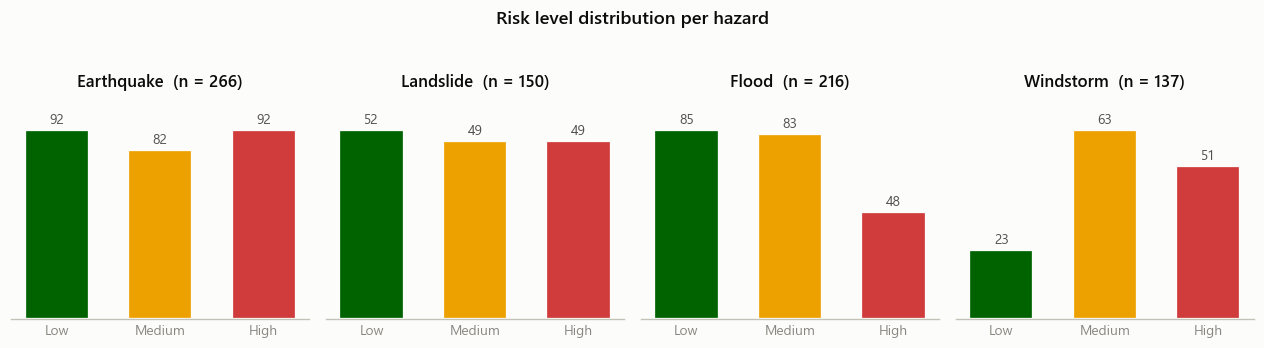

In [7]:
fig = class_balance_figure(datasets)

The windstorm dataset keeps a real minority in the Low class. This is why the
evaluation later relies on macro averaged F1 and balanced accuracy rather
than plain accuracy, and why the tuning grids include balanced class
weights.

## 5. What the surveyed stock looks like

The distribution of every earthquake attribute, ordered from the most
favorable category to the least favorable one. The picture is typical of
rural school stock: single story buildings, confined or partially confined
masonry, gabled roofs with fiber cement or clay covering, and a meaningful
share of buildings with visible damage or missing ring beams.

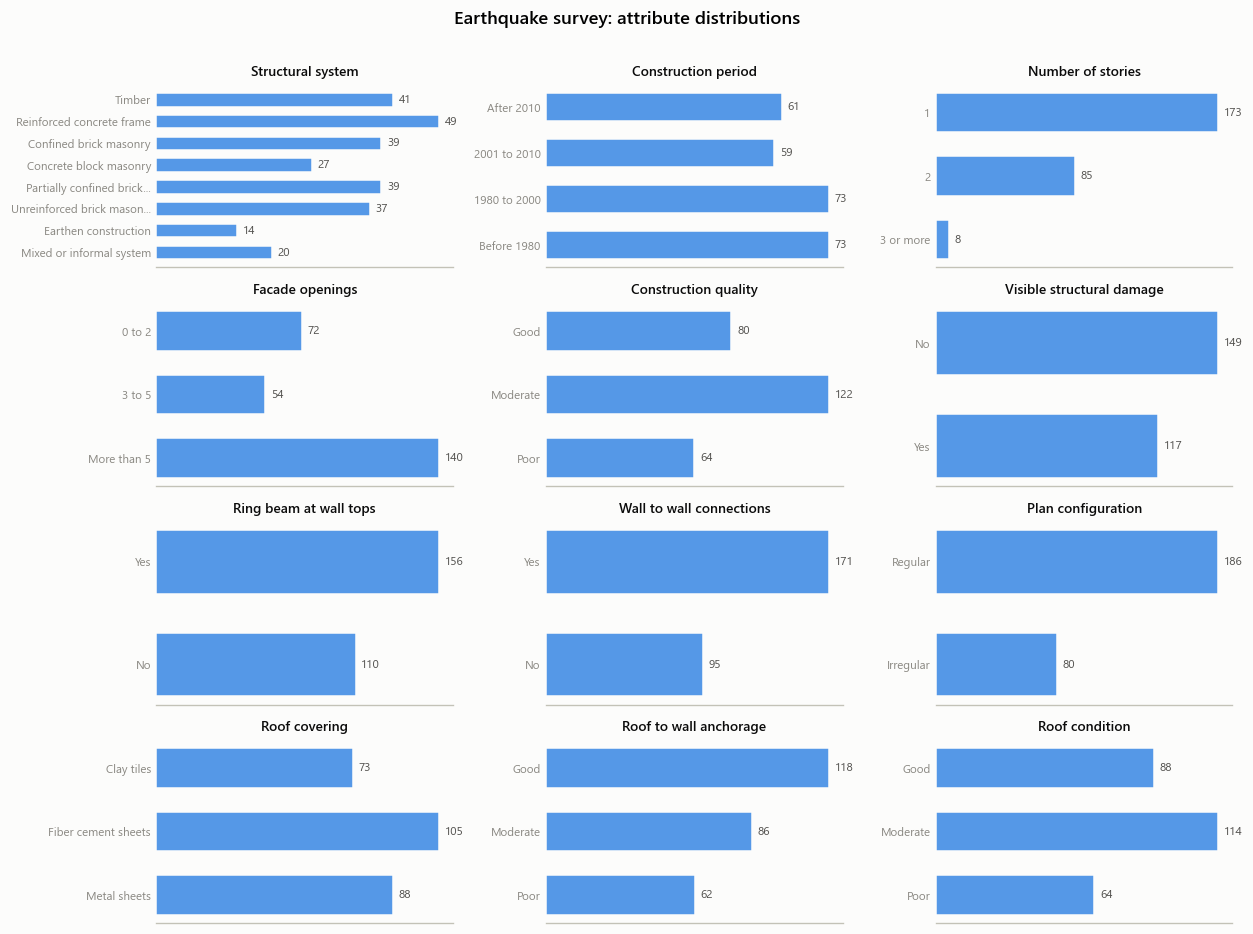

In [8]:
import math

import matplotlib.pyplot as plt

from schoolrisk.plots import INK_SOFT, SURFACE

schema = HAZARDS["earthquake"]
df = datasets["earthquake"]

n_cols = 3
n_rows = math.ceil(len(schema.features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.5, 2.1 * n_rows))
for ax in axes.ravel()[len(schema.features):]:
    ax.set_visible(False)
for ax, (feature, order) in zip(axes.ravel(), schema.features.items()):
    counts = df[feature].value_counts().reindex(list(order)).fillna(0)
    ax.barh(
        [v if len(v) < 26 else v[:24] + "..." for v in counts.index],
        counts.values,
        color="#5598e7", height=0.62, edgecolor=SURFACE, linewidth=1.0,
    )
    for y, value in enumerate(counts.values):
        ax.text(value + counts.max() * 0.02, y, f"{int(value)}",
                va="center", fontsize=7.6, color=INK_SOFT)
    ax.invert_yaxis()
    ax.set_title(schema.display_name(feature), fontsize=9)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=7.6, length=0)
    ax.spines["left"].set_visible(False)
fig.suptitle("Earthquake survey: attribute distributions", fontsize=12,
             fontweight="semibold", y=1.005)
fig.tight_layout()

## 6. How attributes interact

A quick cross tabulation shows the age and system interplay: recent buildings
concentrate in engineered systems, while the oldest stock concentrates in
unreinforced masonry and earthen construction. Patterns like this one are
what the models will exploit.

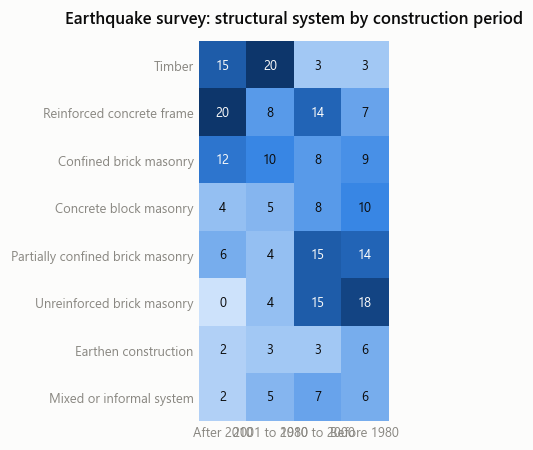

In [9]:
import numpy as np

pivot = pd.crosstab(
    datasets["earthquake"]["structural_system"],
    datasets["earthquake"]["construction_period"],
)
pivot = pivot.reindex(index=list(schema.features["structural_system"]),
                      columns=list(schema.features["construction_period"]))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
im = ax.imshow(pivot.values, cmap=SEQ_CMAP)
ax.set_xticks(range(pivot.shape[1]), pivot.columns, fontsize=8.5)
ax.set_yticks(range(pivot.shape[0]), pivot.index, fontsize=8.5)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.values[i, j]
        color = "#fcfcfb" if value > pivot.values.max() * 0.55 else "#0b0b0b"
        ax.text(j, i, value, ha="center", va="center", fontsize=8.5, color=color)
ax.set_title("Earthquake survey: structural system by construction period", pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()

## Takeaways

* Four hazard specific datasets share one categorical vocabulary with expert
  defined severity orderings, which suits ordinal encoding and tree ensembles.
* Classes are balanced by construction for three hazards; windstorm keeps a
  genuine Low minority, so macro metrics will anchor the evaluation.
* Exact duplicates are removed before any split to keep the holdout honest.

The next notebook selects and tunes the models.